<a href="https://colab.research.google.com/github/Ysabellyysa/Python/blob/main/Imagens_Neural_Style_Pr%C3%A1tica.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install torch_snippets
from torch_snippets import *
import torchvision.datasets as datasets
import torchvision.transforms as T
import torch.nn as nn
import torch.nn.functional as F
device = 'cuda' if torch.cuda.is_available() else 'cpu'


In [2]:
data_folder = './CIFAR10'
datasets.CIFAR10(data_folder, download=True)
class SuperResolutionDataset(torchvision.datasets.CIFAR10):
    def __init__(self, root, train=True):
        super().__init__(root, train=train)
        #tansformação para simular baixa resolução na entrada
        self.low_res_transform = T.Compose([
            T.Resize((16, 16)),
            T.Resize((32, 32), interpolation=T.InterpolationMode.BICUBIC)])
    def __getitem__(self, ix):
        im, _ = super().__getitem__(ix)
        # Imagem de entrada e imagem alvo
        low_res_im = self.low_res_transform(im)
        low_res_arr = np.array(low_res_im) / 255.0
        high_res_arr = np.array(im) / 255.0
        low_res_tensor, high_res_tensor = [
            torch.tensor(img).permute(2, 0, 1).to(device).float()
            for img in [low_res_arr, high_res_arr]]
        return low_res_tensor, high_res_tensor
trn_ds = SuperResolutionDataset(data_folder, train=True)
val_ds = SuperResolutionDataset(data_folder, train=False)
trn_dl = DataLoader(trn_ds, batch_size=128, shuffle=True)
val_dl = DataLoader(val_ds, batch_size=128, shuffle=False)

100%|██████████| 170M/170M [11:30<00:00, 247kB/s]


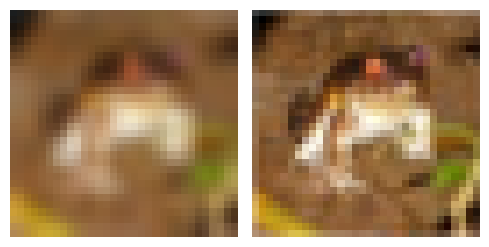

In [3]:
#vendo as amostras
low_img, high_img = trn_ds[0]
subplots([low_img.cpu().permute(1, 2, 0), high_img.cpu().permute(1, 2, 0)], nc=2)

In [4]:
class SuperResModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2) # Reduz a dimensionalidade espacial
            )
        # reconstruindo imagem
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2), #expande de volta
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 3, kernel_size=3, padding=1),
            nn.Sigmoid() #garante valores de pixel entre 0 e 1
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

In [5]:
def get_model():
    model = SuperResModel().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loss_fn = nn.MSELoss() #reconstrução de pixel
    return model, optimizer, loss_fn
model, optimizer, loss_fn = get_model()

In [6]:
#função de treinamento e validação por lote
def train_batch(model, data, optimizer, criterion):
    model.train()
    x, y = data
    _y = model(x)
    optimizer.zero_grad()
    loss = criterion(_y, y)
    loss.backward()
    optimizer.step()
    return loss.item()
@torch.no_grad()
def validate_batch(model, data, criterion):
    model.eval()
    x, y = data
    _y = model(x)
    loss = criterion(_y, y)
    return loss.item()

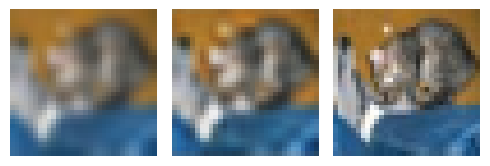

In [10]:
#testando modelo treinado em uma imagem
model.eval()
with torch.no_grad():
    sample_low, sample_high = val_ds[0]
    predicted_high = model(sample_low.unsqueeze(0))[0]
    subplots([
        sample_low.cpu().permute(1, 2, 0),
        predicted_high.cpu().permute(1, 2, 0),
        sample_high.cpu().permute(1, 2, 0)
    ], nc=3)